In [ ]:
# libraries 
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# load data
df = pd.read_csv("nyts2022_ecig_ml_complete.csv")

df.head()

,newid,age,sex,grade,peer_ecig_susceptibility,household_tobacco_use,perceived_harm_original,perceived_harm_binary,ever_used_ecig
0,103102,4,2,2,4.0,0,3,1,0
1,103103,5,2,2,2.0,1,1,0,0
2,103104,4,1,2,4.0,0,4,1,0
3,103105,5,1,2,3.0,0,2,0,0
4,103107,3,1,1,3.0,0,4,1,0


In [ ]:
# check data ovreall and missing values
print(df.shape)
print(df.isnull().sum())

(23682, 9)
newid                          0
age                            0
sex                            0
grade                          0
peer_ecig_susceptibility    4596
household_tobacco_use          0
perceived_harm_original        0
perceived_harm_binary          0
ever_used_ecig                 0
dtype: int64


In [ ]:
df['peer_ecig_susceptibility'].median()

4.0

In [ ]:
df['peer_ecig_susceptibility'].mode()[0]

np.float64(4.0)

In [ ]:
#address missing value for susceptibility with filling it in with median
df['peer_ecig_susceptibility'] = (df['peer_ecig_susceptibility'].fillna(df['peer_ecig_susceptibility'].median()))

In [ ]:
# set predictors and outcome of ever use
X = df[
    [
        'age',
        'sex',
        'grade',
        'peer_ecig_susceptibility',
        'household_tobacco_use',
        'perceived_harm_binary'
    ]
]

y = df['ever_used_ecig']

In [ ]:
#70/30 train-test split with stratification to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [ ]:
# create ML methods (with class imbalance handling)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        class_weight='balanced'
    )
}

In [ ]:
#train and evaluate ML models
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)
results_df

,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.734975,0.406421,0.813139,0.541961,0.851010
1,Decision Tree,0.737368,0.407255,0.794891,0.538576,0.844144
2,Random Forest,0.738916,0.408732,0.792701,0.539359,0.845308


In [ ]:
#evaluate LR
log_model = models["Logistic Regression"]

y_pred_log = log_model.predict(X_test)

print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

[[4108 1627]
 [ 256 1114]]
              precision    recall  f1-score   support

           0       0.94      0.72      0.81      5735
           1       0.41      0.81      0.54      1370

    accuracy                           0.73      7105
   macro avg       0.67      0.76      0.68      7105
weighted avg       0.84      0.73      0.76      7105



In [ ]:
#LR coefficients 
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": log_model.coef_[0]
})

coef_df.sort_values(by="coefficient", ascending=False)

<Figure size 800x600 with 0 Axes>

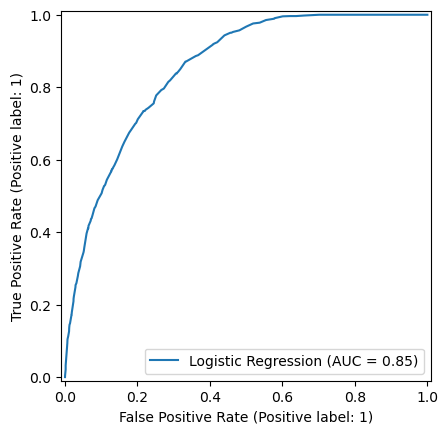

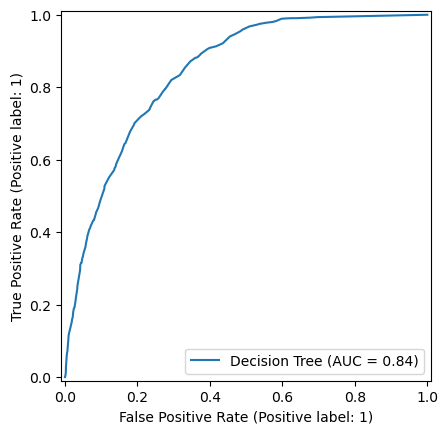

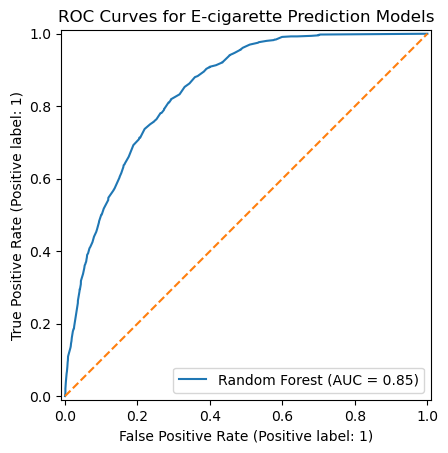

In [ ]:
#visualize ROC Curves for E-cigarette Prediction Models

import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8,6))

for name, model in models.items():
    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        name=name
    )

plt.plot([0,1], [0,1], linestyle='--')
plt.title('ROC Curves for E-cigarette Prediction Models')
plt.show()

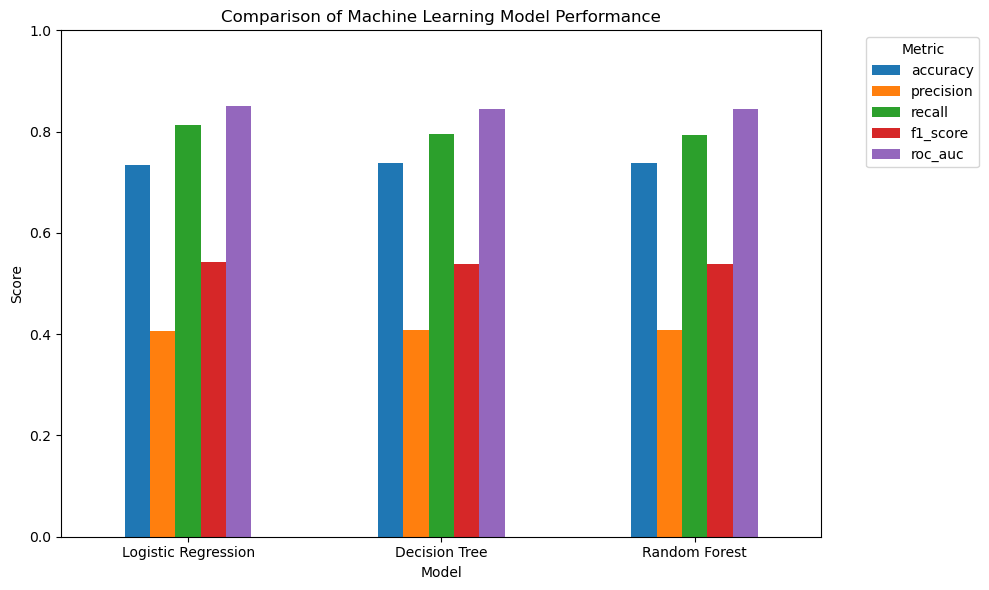

In [ ]:
#Visual barchart

results_plot = results_df.set_index('model')

results_plot[
    ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']
].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Comparison of Machine Learning Model Performance')
plt.ylabel('Score')
plt.xlabel('Model')
plt.ylim(0,1)

plt.xticks(rotation=0)

plt.legend(
    title='Metric',
    bbox_to_anchor=(1.05,1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

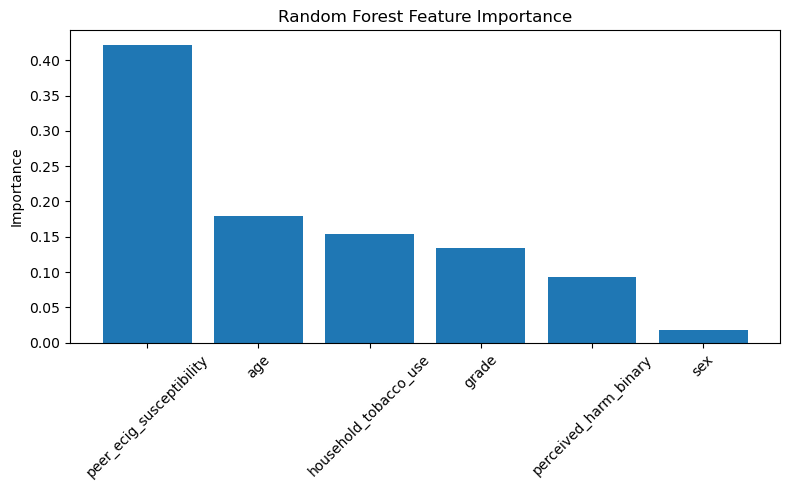

In [ ]:
#Visual for predictors that mattered the most, Random forest

rf_model = models["Random Forest"]

importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='importance',
    ascending=False
)

plt.figure(figsize=(8,5))

plt.bar(
    importance_df['feature'],
    importance_df['importance']
)

plt.title('Random Forest Feature Importance')
plt.ylabel('Importance')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

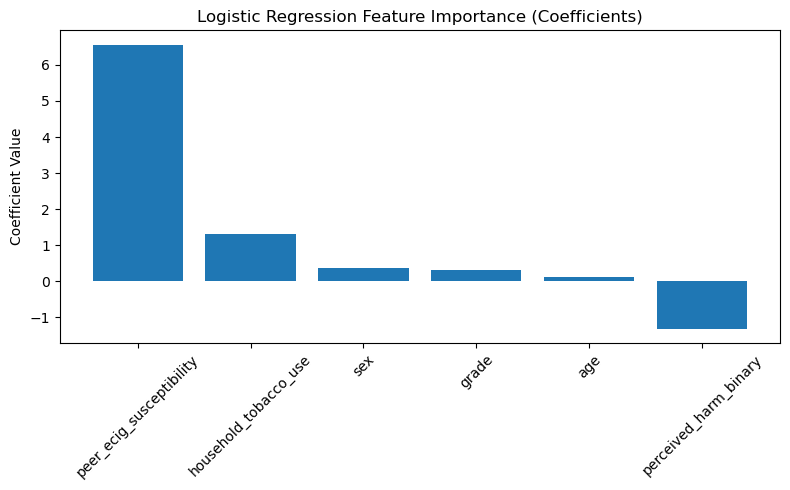

In [ ]:
##Visual for predictors that mattered the most, Logistic Regression
lr_model = models["Logistic Regression"]

importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': lr_model.coef_[0]
})

importance_df = importance_df.sort_values(
    by='importance',
    ascending=False
)

plt.figure(figsize=(8,5))

plt.bar(
    importance_df['feature'],
    importance_df['importance']
)

plt.title('Logistic Regression Feature Importance (Coefficients)')
plt.ylabel('Coefficient Value')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()